In [1]:
!python -m pip install --upgrade pip

In [2]:
!pip install pandasai

  Using cached pandas-1.5.3-cp310-cp310-win_amd64.whl.metadata (12 kB)
Using cached pandas-1.5.3-cp310-cp310-win_amd64.whl (10.4 MB)
  Attempting uninstall: pandas
    Found existing installation: pandas 2.3.3
    Uninstalling pandas-2.3.3:
      Successfully uninstalled pandas-2.3.3


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
wfdb 4.3.1 requires pandas>=2.2.3, but you have pandas 1.5.3 which is incompatible.


In [3]:
pip install pandasai openai pandas==1.5.3

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
from pandasai import SmartDataframe
from pandasai.llm.openai import OpenAI

In [5]:
df = pd.read_csv("IPL_Squad_2023_Auction_Dataset.csv")
df.head()

,Unnamed: 0,Player's List,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2022 Squad,Team
0,0,Shivam Mavi,4000000,BOWLER,6.0,720.0,KKR,Gujarat Titans
1,1,Joshua Little,5000000,BOWLER,4.4,528.0,NaN,Gujarat Titans
2,2,Kane Williamson,20000000,BATSMAN,2.0,240.0,SRH,Gujarat Titans
3,3,K.S. Bharat,2000000,WICKETKEEPER,1.2,144.0,DC,Gujarat Titans
4,4,Mohit Sharma,5000000,BOWLER,0.5,60.0,NaN,Gujarat Titans


In [8]:
df.sort_values(by="COST IN ₹ (CR.)", ascending=False)[["Player's List", "COST IN ₹ (CR.)"]].head(3)

,Player's List,COST IN ₹ (CR.)
97,Sam Curran,18.50
144,Cameron Green,17.50
25,Ben Stokes,16.25


In [1]:
import pandas as pd

df = pd.read_csv("IPL_Squad_2023_Auction_Dataset.csv")
df.head()

,Unnamed: 0,Player's List,Base Price,TYPE,COST IN ₹ (CR.),Cost IN $ (000),2022 Squad,Team
0,0,Shivam Mavi,4000000,BOWLER,6.0,720.0,KKR,Gujarat Titans
1,1,Joshua Little,5000000,BOWLER,4.4,528.0,NaN,Gujarat Titans
2,2,Kane Williamson,20000000,BATSMAN,2.0,240.0,SRH,Gujarat Titans
3,3,K.S. Bharat,2000000,WICKETKEEPER,1.2,144.0,DC,Gujarat Titans
4,4,Mohit Sharma,5000000,BOWLER,0.5,60.0,NaN,Gujarat Titans


In [2]:
df.drop(['Unnamed: 0'], axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568 entries, 0 to 567
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Player's List    568 non-null    object 
 1   Base Price       568 non-null    object 
 2   TYPE             568 non-null    object 
 3   COST IN ₹ (CR.)  243 non-null    float64
 4   Cost IN $ (000)  243 non-null    float64
 5   2022 Squad       230 non-null    object 
 6   Team             568 non-null    object 
dtypes: float64(2), object(5)
memory usage: 31.2+ KB


In [3]:
df.sort_values(by="COST IN ₹ (CR.)", ascending=False)[
    ["Player's List", "COST IN ₹ (CR.)"]
].head(5)

,Player's List,COST IN ₹ (CR.)
97,Sam Curran,18.50
144,Cameron Green,17.50
25,Ben Stokes,16.25
119,Nicholas Pooran,16.00
218,Harry Brook,13.25


In [4]:
df.sort_values(by="COST IN ₹ (CR.)")[[
    "Player's List", "Team", "COST IN ₹ (CR.)"
]].head(10)

,Player's List,Team,COST IN ₹ (CR.)
242,Glenn Phillips,Sunrisers Hyderabad,0.0
117,Raj Angad Bawa,Punjab Super Kings,0.0
118,Rishi Dhawan,Punjab Super Kings,0.0
211,Dhruv Jurel,Rajasthan Royals,0.0
210,K.C Cariappa,Rajasthan Royals,0.0
241,Bhuvneshwar Kumar,Sunrisers Hyderabad,0.0
209,Yashasvi Jaiswal,Rajasthan Royals,0.0
208,Yuzvendra Chahal,Rajasthan Royals,0.0
207,Prasidh Krishna,Rajasthan Royals,0.0
116,Prabhsimran Singh,Punjab Super Kings,0.0


In [5]:
team_spending = df.groupby("Team")["COST IN ₹ (CR.)"].sum()
print(team_spending)

Team
Chennai Super Kings           18.95
Delhi Capitals                15.00
Gujarat Titans                14.80
Kolkata Knight Riders          5.40
Lucknow Super Giants          19.80
Mumbai Indians                20.50
Punjab Super Kings            20.00
Rajasthan Royals               9.85
Royal Challengers Banglore     7.00
Sunrisers Hyderabad           35.70
Unsold                         0.00
Name: COST IN ₹ (CR.), dtype: float64


In [12]:
def plot_team_spending(df):
    spending = df.groupby("Team")["COST IN ₹ (CR.)"].sum()

    spending.plot(kind='barh')
    plt.title("Total Spending by Teams")
    plt.show()

In [7]:
import pandas as pd

def load_data(path):
    df = pd.read_csv(path)
    df.drop(['Unnamed: 0'], axis=1, inplace=True)
    return df

def team_spending(df):
    return df.groupby("Team")["COST IN ₹ (CR.)"].sum().sort_values()

def unsold_players(df):
    return df[df["COST IN ₹ (CR.)"] == 0]

def player_type_distribution(df):
    return df["TYPE"].value_counts()

In [8]:
def plot_team_spending(team_spending):
    import matplotlib.pyplot as plt

    team_spending.plot(kind='barh')
    plt.title("Team Spending Analysis")
    plt.xlabel("Amount (Cr)")
    plt.tight_layout()
    plt.show()

In [9]:
def type_spending(df):
    return df.groupby("TYPE")["COST IN ₹ (CR.)"].sum()

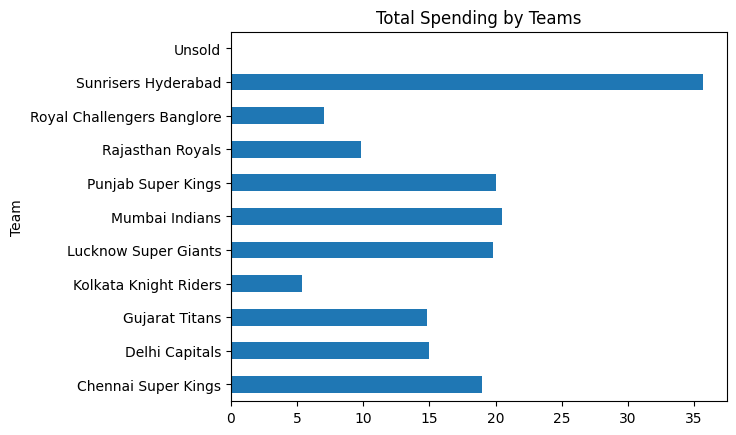

Unsold players: 163


In [13]:
if __name__ == "__main__":
    df = load_data("IPL_Squad_2023_Auction_Dataset.csv")

    plot_team_spending(df)

    unsold = unsold_players(df)
    print("Unsold players:", len(unsold))

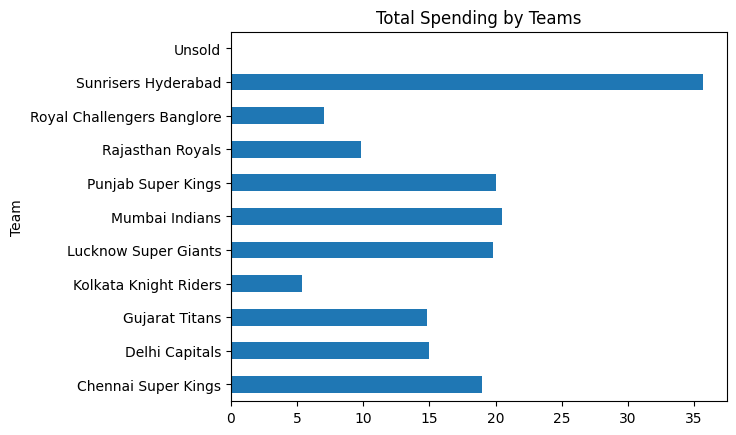

163
ALL-ROUNDER     213
BOWLER          189
BATSMAN          91
WICKETKEEPER     75
Name: TYPE, dtype: int64


In [14]:
df = load_data("IPL_Squad_2023_Auction_Dataset.csv")

plot_team_spending(df)

print(len(unsold_players(df)))

print(df["TYPE"].value_counts())

In [15]:
type_avg = df.groupby("TYPE")["COST IN ₹ (CR.)"].mean()
print(type_avg)

TYPE
ALL-ROUNDER     0.813218
BATSMAN         0.890244
BOWLER          0.378235
WICKETKEEPER    0.920000
Name: COST IN ₹ (CR.), dtype: float64


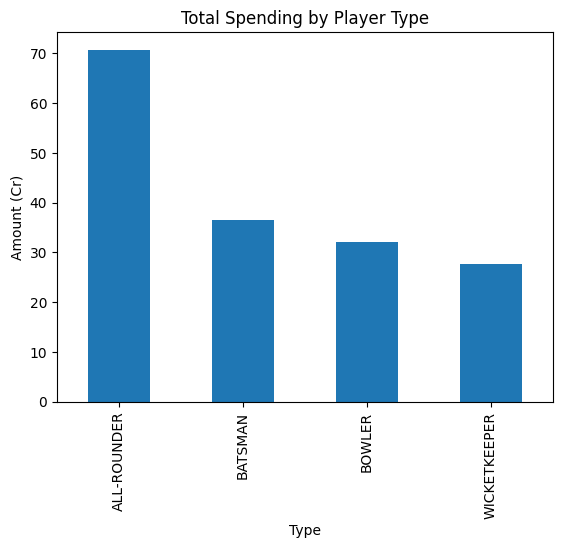

In [16]:
type_spend = df.groupby("TYPE")["COST IN ₹ (CR.)"].sum()

type_spend.plot(kind='bar')
plt.title("Total Spending by Player Type")
plt.xlabel("Type")
plt.ylabel("Amount (Cr)")
plt.show()

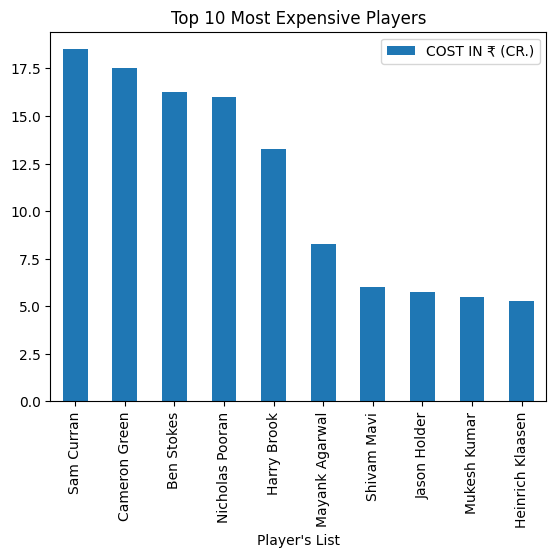

In [19]:
top_players = df.sort_values("COST IN ₹ (CR.)", ascending=False).head(10)

top_players.plot(
    x="Player's List",
    y="COST IN ₹ (CR.)",
    kind="bar"
)
plt.title("Top 10 Most Expensive Players")
plt.xticks(rotation=90)
plt.show()

In [20]:
df["Price Category"] = pd.cut(
    df["COST IN ₹ (CR.)"],
    bins=[-1, 2, 5, 10, 20],
    labels=["Low", "Medium", "High", "Very High"]
)

In [21]:
print(df["Price Category"].value_counts())

Low          228
Medium         5
High           5
Very High      5
Name: Price Category, dtype: int64
